In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from helper import analyze_data

In [4]:
data = pd.read_csv("../Data/all_data.csv")

In [5]:
data.head()

,id,age,tenure,service_type,avg_call_duration,data_usage,roaming_usage,monthly_charge,overdue_payments,auto_payment,avg_top_up_count,call_drops,customer_support_calls,satisfaction_score,churn,İzleGo,RitimGo,CüzdanX,HızlıPazar,Konuşalım
0,640fb410-d433-4263-804c-329239abbcef,48,82.0,Postpaid,72.90,25.98,26.82,1083.31,1,1.0,0,14.0,4,2.51,0,0,0,0,0,0
1,0aa936ce-be1a-4508-9202-6c85ba1041ae,55,274.0,Postpaid,57.28,114.99,49.66,159.72,3,1.0,0,9.0,15,6.30,0,0,0,0,0,0
2,24324272-c0b1-4aee-b22d-c3c4e5d759af,34,81.0,Postpaid,2.07,158.35,13.74,770.14,2,0.0,0,8.0,0,1.35,0,0,0,0,0,0
3,b1e8c3cb-c078-4a06-b77e-65d7ed5b13d8,59,213.0,Postpaid,7.34,42.23,30.66,597.18,2,1.0,0,7.0,0,5.79,0,0,0,0,0,0
4,06e31555-bcd8-42d6-a574-96a2188b82df,18,56.0,Prepaid,58.63,46.94,40.87,2173.60,0,NaN,60,7.0,6,1.14,0,0,0,0,0,0


In [6]:
data.drop(columns=["id"], axis=1, inplace=True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 19 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   age                     int64  
 1   tenure                  float64
 2   service_type            object 
 3   avg_call_duration       float64
 4   data_usage              float64
 5   roaming_usage           float64
 6   monthly_charge          float64
 7   overdue_payments        int64  
 8   auto_payment            float64
 9   avg_top_up_count        int64  
 10  call_drops              float64
 11  customer_support_calls  int64  
 12  satisfaction_score      float64
 13  churn                   int64  
 14  İzleGo                  int64  
 15  RitimGo                 int64  
 16  CüzdanX                 int64  
 17  HızlıPazar              int64  
 18  Konuşalım               int64  
dtypes: float64(8), int64(10), object(1)
memory usage: 1.4+ GB


In [8]:
data.isna().sum()

age                             0
tenure                      24800
service_type                    0
avg_call_duration         3664313
data_usage                 499533
roaming_usage             3331212
monthly_charge             250071
overdue_payments                0
auto_payment              3344748
avg_top_up_count                0
call_drops                3331212
customer_support_calls          0
satisfaction_score              0
churn                           0
İzleGo                          0
RitimGo                         0
CüzdanX                         0
HızlıPazar                      0
Konuşalım                       0
dtype: int64

In [9]:
cat_cols, num_cols, cat_but_car = analyze_data(data)

Number of Observations: 10000000
Number of Variables: 19
Cat cols: 9, Num cols: 10, Cat but car cols: 0


In [10]:
data[cat_cols].head()

,service_type,overdue_payments,auto_payment,churn,İzleGo,RitimGo,CüzdanX,HızlıPazar,Konuşalım
0,Postpaid,1,1.0,0,0,0,0,0,0
1,Postpaid,3,1.0,0,0,0,0,0,0
2,Postpaid,2,0.0,0,0,0,0,0,0
3,Postpaid,2,1.0,0,0,0,0,0,0
4,Prepaid,0,NaN,0,0,0,0,0,0


In [11]:
data[cat_cols].isna().sum()

service_type              0
overdue_payments          0
auto_payment        3344748
churn                     0
İzleGo                    0
RitimGo                   0
CüzdanX                   0
HızlıPazar                0
Konuşalım                 0
dtype: int64

In [12]:
data[num_cols].head()

,age,tenure,avg_call_duration,data_usage,roaming_usage,monthly_charge,avg_top_up_count,call_drops,customer_support_calls,satisfaction_score
0,48,82.0,72.90,25.98,26.82,1083.31,0,14.0,4,2.51
1,55,274.0,57.28,114.99,49.66,159.72,0,9.0,15,6.30
2,34,81.0,2.07,158.35,13.74,770.14,0,8.0,0,1.35
3,59,213.0,7.34,42.23,30.66,597.18,0,7.0,0,5.79
4,18,56.0,58.63,46.94,40.87,2173.60,60,7.0,6,1.14


In [13]:
data[num_cols].isna().sum()

age                             0
tenure                      24800
avg_call_duration         3664313
data_usage                 499533
roaming_usage             3331212
monthly_charge             250071
avg_top_up_count                0
call_drops                3331212
customer_support_calls          0
satisfaction_score              0
dtype: int64

C:\Users\osman\AppData\Local\Temp\ipykernel_6840\449897991.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  null_ratios = data.groupby(["service_type"]).apply(lambda x: x.nunique() )


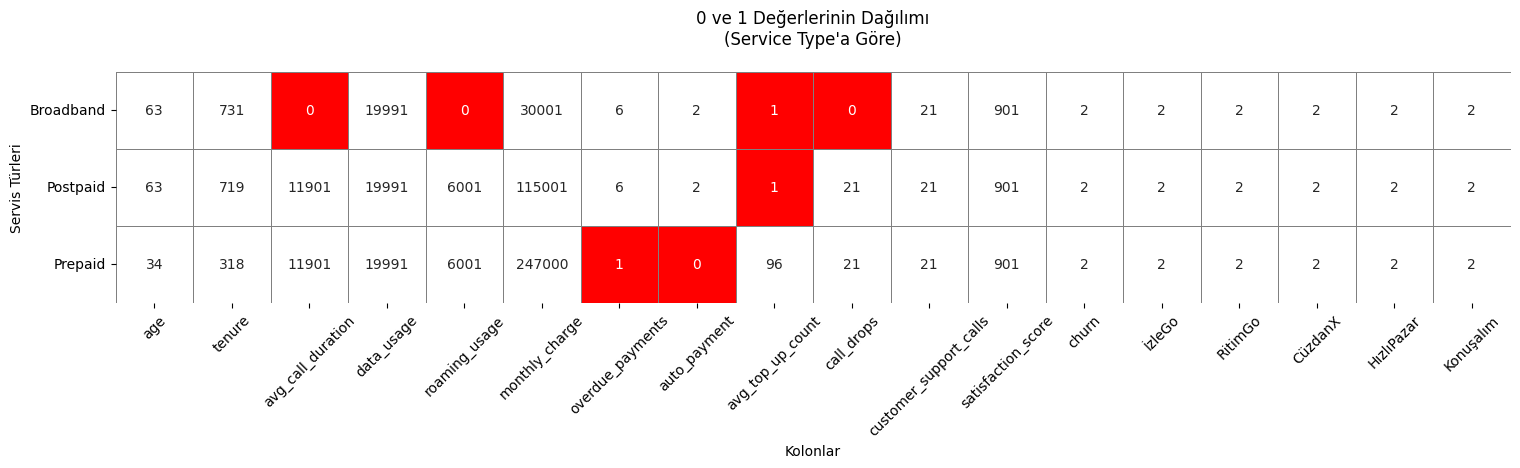

In [14]:
null_ratios = data.groupby(["service_type"]).apply(lambda x: x.nunique() )
null_ratios.drop(["service_type"], axis=1, inplace=True)
plt.figure(figsize=(18, 3))

cmap = sns.color_palette(["white", "red"], as_cmap=True)

mask = null_ratios.isin([0, 1])
sns.heatmap(
    mask,
    cmap=cmap,
    annot=null_ratios,
    fmt="d",
    linewidths=0.5,
    linecolor="gray",
    cbar=False
)

plt.title("0 ve 1 Değerlerinin Dağılımı\n(Service Type'a Göre)", pad=20)
plt.xlabel("Kolonlar")
plt.ylabel("Servis Türleri")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# 📊 **Görsel Açıklaması: "Service Type'a Göre 0 ve 1 Değer Dağılımı"**

## **Görselin Amacı**
Bu görsel, her bir `service_type` grubunda **kolonların ne kadar anlamlı veri içerdiğini** analiz etmek için tasarlandı. Özellikle:
- **0**: İlgili kolonda tüm değerlerin `null` olduğunu,
- **1**: İlgili kolonda tüm değerlerin aynı (sabit) olduğunu vurgular.

---

## **Nasıl Okunur?**
| Bileşen               | Açıklama                                                                 |
|-----------------------|-------------------------------------------------------------------------|
| **Yatay Eksen (X)**   | Veri setindeki kolonlar.      |
| **Dikey Eksen (Y)**   | `service_type` grupları.                     |
| **Hücreler**          | - **Kırmızı**: 0 veya 1 değeri (veri kalitesi sorunu veya anlamsız sütun). <br> - **Beyaz**: 1'den fazla benzersiz değer (anlamlı varyasyon). |
| **Hücre İçindeki Sayı** | İlgili `service_type` ve kolondaki **benzersiz değer sayısı** (`nunique`). |

---

## **Örnek Senaryolar**
1. **Kırmızı Hücre & 0 Değeri**  
   - **Ne Anlama Gelir?**  
     Örneğin, `service_type=broadband` için `avg_call_duration` kolonu **0** ise:  
     *"Bu servis türünde Çağrı Süresiyle ilişkili veri toplanmamış veya bu kolon geçerli değil."*

2. **Kırmızı Hücre & 1 Değeri**  
   - **Ne Anlama Gelir?**  
     Örneğin, `service_type=prepaid` için `overdue_payments` **1** ise:  
     *"Bu servis türünde tüm müşteriler aynı ödeme gecikme sayısına."*

---

## **Ana Çıkarımlar**
- 🚩 **Kırmızı Alanlar**:  
  - **Veri Kalitesi Sorunu**: Null değerler veya sabit değerler içeren kolonlar.  
  - **Servis Özellikleri**: Bazı kolonların belirli servis türleri için gereksiz olduğunu gösterir.  
- ✅ **Beyaz Alanlar**:  
  - **Anlamlı Varyasyon**: İlgili kolonun analiz veya modelleme için potansiyel önemi olduğunu gösterir.


#

In [15]:
broadband_df = data[data["service_type"] == "Broadband"].copy()
postpaid_df = data[data["service_type"] == "Postpaid"].copy()
prepaid_df = data[data["service_type"] == "Prepaid"].copy()

In [16]:
bro_drops, pre_drops, post_drops = [], [], []
for col in data.columns:
    if broadband_df[col].nunique() <= 1:
        bro_drops.append(col)
    if postpaid_df[col].nunique() <= 1:
        post_drops.append(col)
    if prepaid_df[col].nunique() <=1:
        pre_drops.append(col)


In [17]:
broadband_df.drop(columns=bro_drops, axis=1, inplace=True)
prepaid_df.drop(columns=pre_drops, axis=1, inplace=True)
postpaid_df.drop(columns=post_drops, axis=1, inplace=True)

In [18]:
broadband_df.to_csv("../Data/broadband.csv",index=False)
postpaid_df.to_csv("../Data/postpaid.csv",index=False)
prepaid_df.to_csv("../Data/prepaid.csv",index=False)